# High Frequency Data and Limit Order Books
## Lab 6: DeFi

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

In [2]:
df = pd.read_csv('Data/uniswap_v3.csv.gz')
df.head()

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0
3,0.000000,0.000000,0.000000,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,394,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257915,NaN,NaN,0x9e90c83df6f83931b6c04212ff773c43baa38f28271d...,1768694471,NaN,71.0
4,0.000000,0.000000,0.000000,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,311,0xdbe936e556048a23c670ae9e3d8e52b2daac558e,NaN,NaN,NaN,NaN,...,0xc36442b4a4522e871399cd717abdd847ab11fe88,0.0,1.0,24257916,NaN,NaN,0xac50b5cb008fc419900c4a1c611ffa883cf1ee29754d...,1768694483,NaN,83.0


---
1. Explore the proposed dataset. Comment, explain.

In [3]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
df.head(3)

Shape: (468192, 24)

Columns: ['amount0', 'amount1', 'amountUSD', 'id', 'logIndex', 'origin', 'recipient', 'sender', 'sqrtPriceX96', 'tick', 'timestamp', 'pool', 'event_type', 'amount', 'owner', 'tickLower', 'tickUpper', 'transaction.blockNumber', 'transaction.gasPrice', 'transaction.gasUsed', 'transaction.id', 'transaction.timestamp', 'price_1_per_0', 't']

Dtypes:
amount0                    float64
amount1                    float64
amountUSD                  float64
id                             str
logIndex                     int64
origin                         str
recipient                      str
sender                         str
sqrtPriceX96                object
tick                       float64
timestamp                      str
pool                           str
event_type                     str
amount                     float64
owner                          str
tickLower                  float64
tickUpper                  float64
transaction.blockNumber      int64
t

,amount0,amount1,amountUSD,id,logIndex,origin,recipient,sender,sqrtPriceX96,tick,...,owner,tickLower,tickUpper,transaction.blockNumber,transaction.gasPrice,transaction.gasUsed,transaction.id,transaction.timestamp,price_1_per_0,t
0,-10.000000,0.003023,9.998842,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,264,0x12f82b9929c92fdf853d9d9b076c32909f25718a,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,1377282103516700331802368117587827,195275.0,...,NaN,NaN,NaN,24257914,1.033162e+09,0.0,0x61821065c5c1b879477c2947f6d52e31b7109b514081...,1768694459,3.021771e+08,59.0
1,0.002699,-8.929703,8.927690,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,221,0x3bae26c9ee93467619ebb3d0dbc3d052243cacb4,0xcdb49866c473bfd0a4dbf64e48d7db2cd31796df,0x8793c6aa63cc96c955da4906f628dc09cd595dc8,4558100686673991521600072,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0xdb0306884d4e52175fbe138bf6733756559b4e39979c...,1768694471,3.309649e-09,71.0
2,0.001749,-5.785837,5.784533,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,288,0x19a4cc064ba710a9ce97499f3c659288bb2ad2dd,0x0b02428e7c2c24ccf64426e637aee0c879bd1860,0x40753445cc591925b49a00d5d727a4fd7049d800,4558100464914553349295265,-195274.0,...,NaN,NaN,NaN,24257915,3.502565e+07,0.0,0x97e93cf4297771d141617459995b59d4b8cd9b9c5209...,1768694471,3.309649e-09,71.0


In [4]:
print(f"Event types:\n{df['event_type'].value_counts()}")
print(f"\nPools:\n{df['pool'].value_counts()}")
print(f"\nTime range: {pd.to_datetime(df['transaction.timestamp'], unit='s').min()} to {pd.to_datetime(df['transaction.timestamp'], unit='s').max()}")
print(f"\nUnique transactions: {df['transaction.id'].nunique()}")
print(f"Unique origins (wallets): {df['origin'].nunique()}")

Event types:
event_type
swap    448989
burn     10036
mint      9167
Name: count, dtype: int64

Pools:
pool
0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640    230249
0x11b815efb8f581194ae79006d24e0d814b7697f6    151283
0x3416cf6c708da44db2624d63ea0aaef7113527c6     45334
0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8     27757
0xcbcdf9626bc03e24f779434178a73a0b4bad62ed     13569
Name: count, dtype: int64

Time range: 2026-01-18 00:00:59 to 2026-02-16 23:59:59

Unique transactions: 398708
Unique origins (wallets): 66370


In [5]:
print(f"amountUSD stats:\n{df['amountUSD'].describe()}")
print(f"\namountUSD by event type:")
print(df.groupby('event_type')['amountUSD'].describe())

amountUSD stats:
count    4.681920e+05
mean     3.233954e+04
std      2.054228e+05
min      0.000000e+00
25%      1.531563e+02
50%      1.915756e+03
75%      8.548032e+03
max      2.582459e+07
Name: amountUSD, dtype: float64

amountUSD by event type:
               count           mean            std           min         25%  \
event_type                                                                     
burn         10036.0  344655.083200  865313.593970  0.000000e+00    0.000000   
mint          9167.0  375989.112418  878339.221192  1.000000e-06  302.291729   
swap        448989.0   18342.241158   82044.006646  1.900000e-15  161.472082   

                    50%            75%           max  
event_type                                            
burn         738.272030   60707.561283  2.580929e+07  
mint        2371.713814  117792.426663  2.582459e+07  
swap        1918.462616    8250.266972  1.008026e+07  


In [ ]:
# Map pool addresses to known Uniswap V3 pairs
pool_names = {
    '0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640': 'USDC/WETH 0.05%',
    '0x11b815efb8f581194ae79006d24e0d814b7697f6': 'WETH/USDT 0.05%',
    '0x3416cf6c708da44db2624d63ea0aaef7113527c6': 'USDT/USDC 0.01%',
    '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8': 'USDC/WETH 0.3%',
    '0xcbcdf9626bc03e24f779434178a73a0b4bad62ed': 'WBTC/WETH 0.3%'
}
df['pool_name'] = df['pool'].map(pool_names)
df['datetime'] = pd.to_datetime(df['transaction.timestamp'], unit='s')

print(df.groupby(['pool_name', 'event_type']).size().unstack(fill_value=0))
print(f"\nTotal USD volume by pool:")
print(df.groupby('pool_name')['amountUSD'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

event_type       burn  mint    swap
pool_name                          
USDC/WETH 0.05%  4253  4624  221372
USDC/WETH 0.3%   1807  1049   24901
USDT/USDC 0.01%  1627  1484   42223
WBTC/WETH 0.3%   1046   972   11551
WETH/USDT 0.05%  1303  1038  148942

Total USD volume by pool:
pool_name
USDC/WETH 0.05%    $8,216,280,134
USDT/USDC 0.01%    $3,335,920,238
WETH/USDT 0.05%    $1,874,836,428
USDC/WETH 0.3%     $1,028,794,327
WBTC/WETH 0.3%       $685,283,996
Name: amountUSD, dtype: str


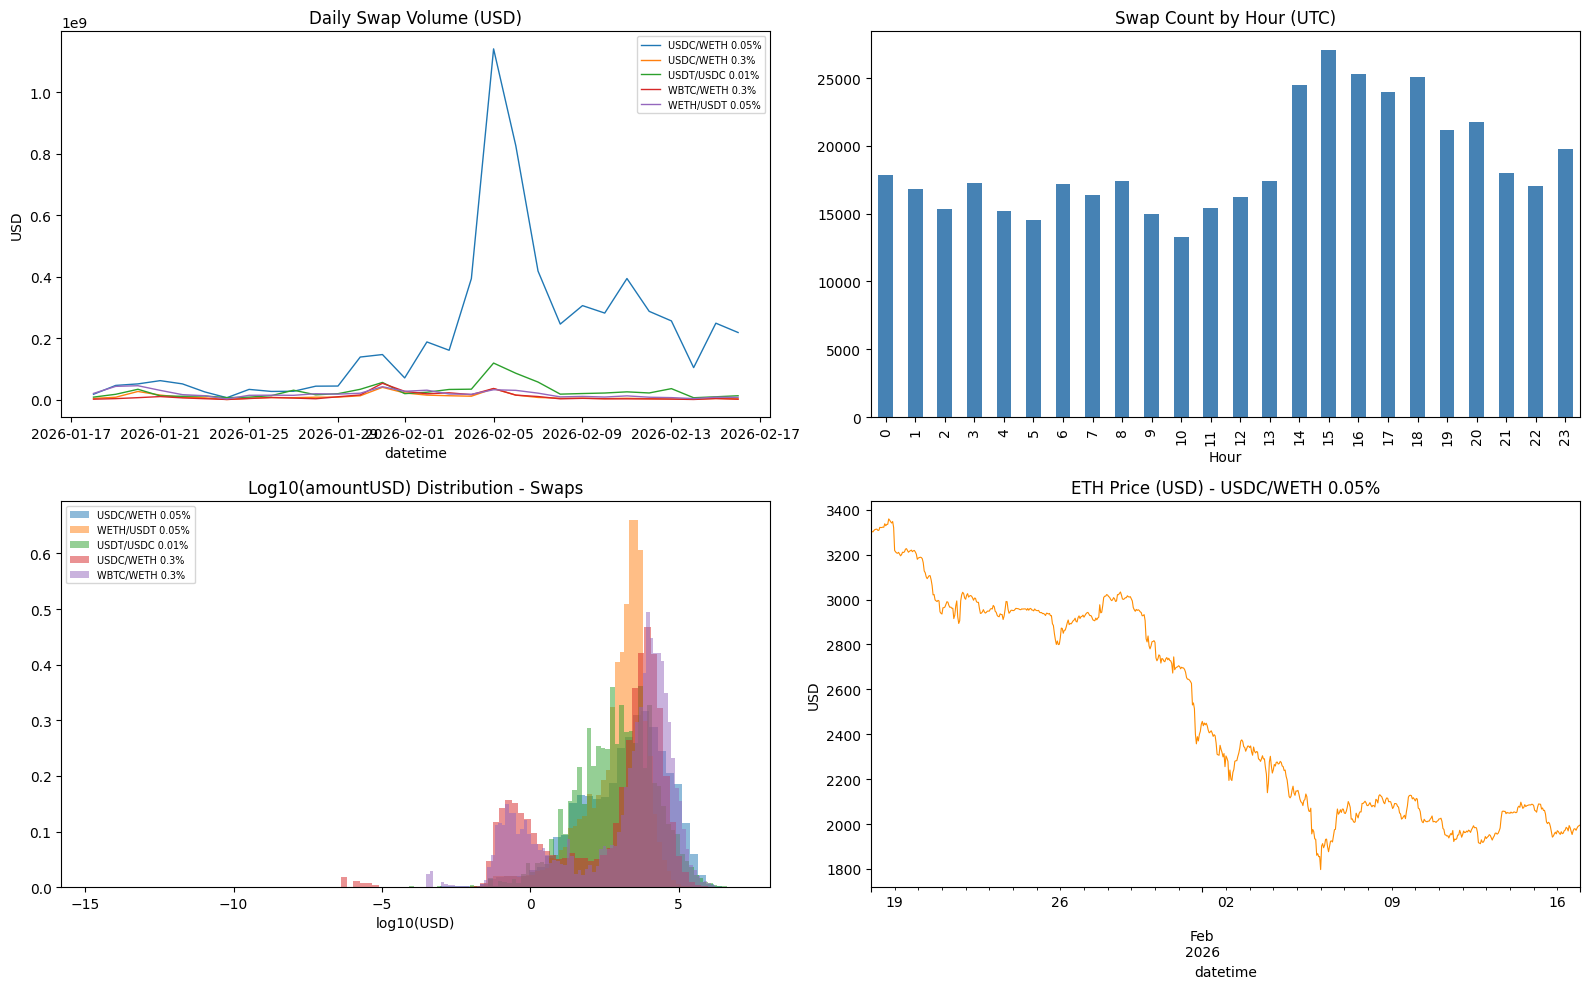

In [ ]:
swaps = df[df['event_type'] == 'swap'].copy()
mints = df[df['event_type'] == 'mint'].copy()
burns = df[df['event_type'] == 'burn'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily swap volume
daily_vol = swaps.groupby([swaps['datetime'].dt.date, 'pool_name'])['amountUSD'].sum().unstack(fill_value=0)
daily_vol.plot(ax=axes[0, 0], linewidth=1)
axes[0, 0].set_title('Daily Swap Volume (USD)')
axes[0, 0].set_ylabel('USD')
axes[0, 0].legend(fontsize=7)

# Hourly swap count
hourly = swaps.groupby(swaps['datetime'].dt.hour).size()
hourly.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Swap Count by Hour (UTC)')
axes[0, 1].set_xlabel('Hour')

# Log distribution of swap sizes
swaps_pos = swaps[swaps['amountUSD'] > 0]
for pool in swaps_pos['pool_name'].unique():
    subset = swaps_pos[swaps_pos['pool_name'] == pool]['amountUSD']
    axes[1, 0].hist(np.log10(subset), bins=80, alpha=0.5, label=pool, density=True)
axes[1, 0].set_title('Log10(amountUSD) Distribution - Swaps')
axes[1, 0].set_xlabel('log10(USD)')
axes[1, 0].legend(fontsize=7)

# ETH price from USDC/WETH 0.05% pool
eth_pool = swaps[swaps['pool_name'] == 'USDC/WETH 0.05%'].copy()
eth_pool = eth_pool.dropna(subset=['price_1_per_0'])
eth_pool = eth_pool.sort_values('datetime')
eth_pool['eth_price'] = 1e12 / eth_pool['price_1_per_0']
eth_pool.set_index('datetime')['eth_price'].resample('1h').median().plot(ax=axes[1, 1], linewidth=0.8, color='darkorange')
axes[1, 1].set_title('ETH Price (USD) - USDC/WETH 0.05%')
axes[1, 1].set_ylabel('USD')

plt.tight_layout()
plt.show()

c:\Users\adoni\Desktop\High-frequency data and limit order books\labs\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adoni\Desktop\High-frequency data and limit order books\labs\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


Transactions with >1 event: 48533 / 398708 (12.2%)
Max events in a single tx: 48


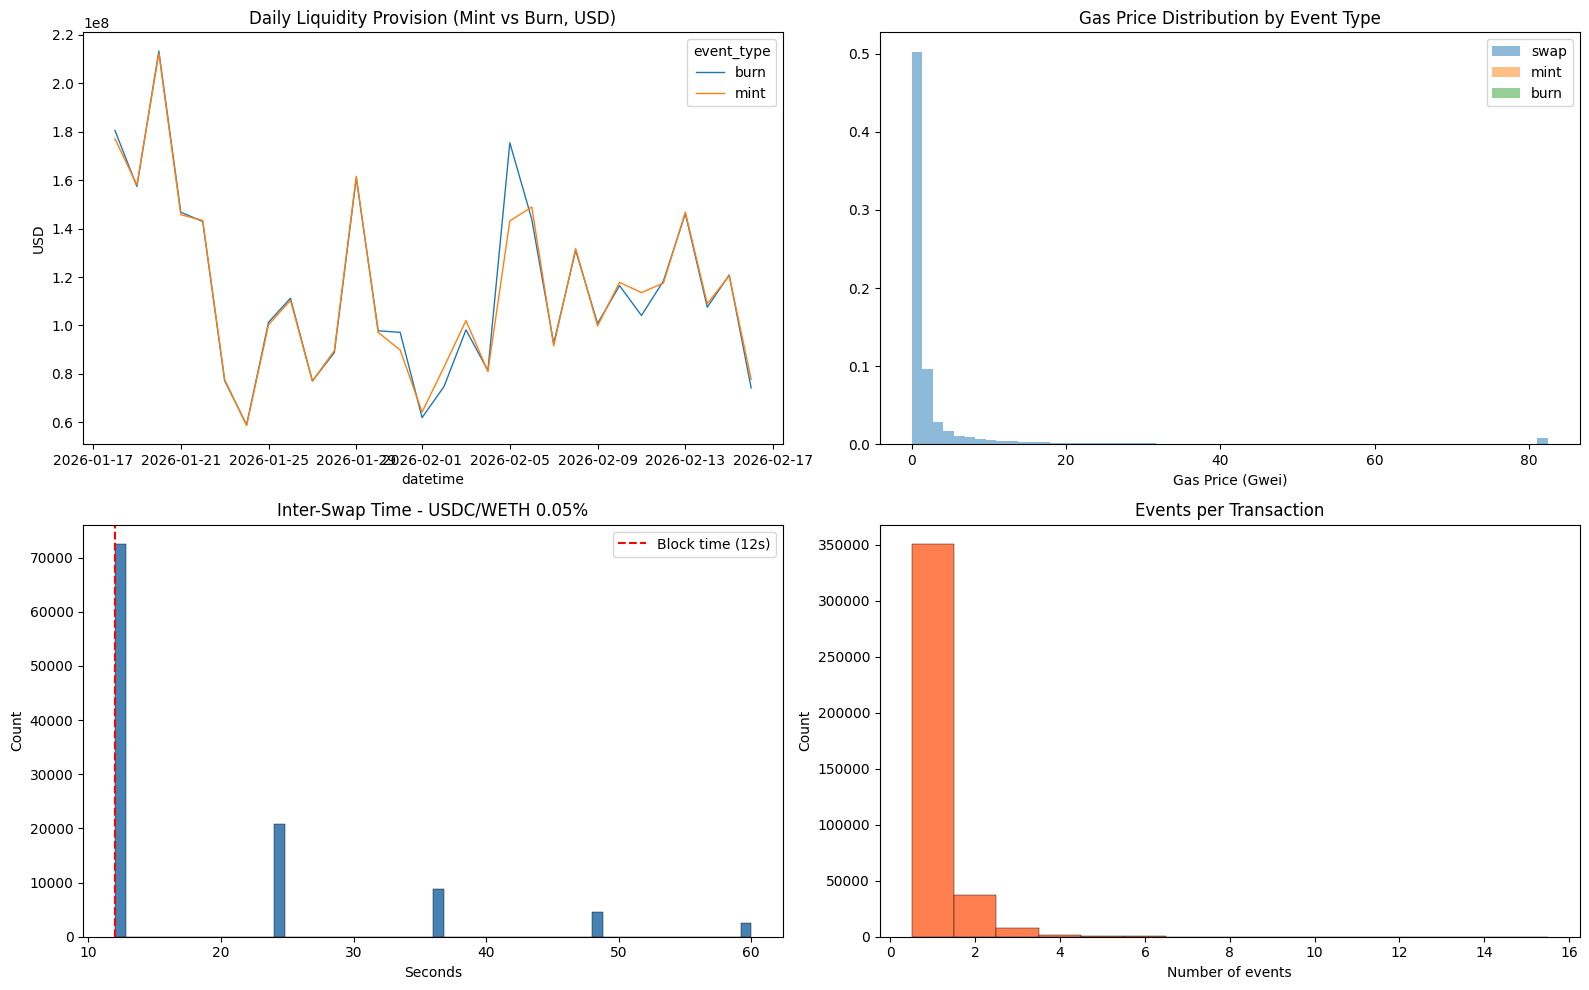

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily mint/burn activity
daily_liq = df[df['event_type'].isin(['mint', 'burn'])].groupby(
    [df['datetime'].dt.date, 'event_type'])['amountUSD'].sum().unstack(fill_value=0)
daily_liq.plot(ax=axes[0, 0], linewidth=1)
axes[0, 0].set_title('Daily Liquidity Provision (Mint vs Burn, USD)')
axes[0, 0].set_ylabel('USD')

# Gas price distribution by event type
gas = df.dropna(subset=['transaction.gasPrice']).copy()
gas['gasGwei'] = gas['transaction.gasPrice'] / 1e9
for et in ['swap', 'mint', 'burn']:
    subset = gas[gas['event_type'] == et]['gasGwei']
    axes[0, 1].hist(subset.clip(upper=subset.quantile(0.99)), bins=60, alpha=0.5, label=et, density=True)
axes[0, 1].set_title('Gas Price Distribution by Event Type')
axes[0, 1].set_xlabel('Gas Price (Gwei)')
axes[0, 1].legend()

# Inter-event times for swaps on USDC/WETH 0.05%
eth_swaps = swaps[swaps['pool_name'] == 'USDC/WETH 0.05%'].sort_values('transaction.timestamp')
iet = eth_swaps['transaction.timestamp'].diff().dropna()
iet = iet[iet > 0]
axes[1, 0].hist(iet[iet <= 60], bins=60, color='steelblue', edgecolor='black', linewidth=0.3)
axes[1, 0].set_title('Inter-Swap Time - USDC/WETH 0.05%')
axes[1, 0].set_xlabel('Seconds')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(12, color='red', linestyle='--', label='Block time (12s)')
axes[1, 0].legend()

# Number of events per transaction
events_per_tx = df.groupby('transaction.id').size()
axes[1, 1].hist(events_per_tx.clip(upper=15), bins=range(1, 17), color='coral', edgecolor='black', linewidth=0.3, align='left')
axes[1, 1].set_title('Events per Transaction')
axes[1, 1].set_xlabel('Number of events')
axes[1, 1].set_ylabel('Count')
print(f"Transactions with >1 event: {(events_per_tx > 1).sum()} / {len(events_per_tx)} ({(events_per_tx > 1).mean()*100:.1f}%)")
print(f"Max events in a single tx: {events_per_tx.max()}")

plt.tight_layout()
plt.show()

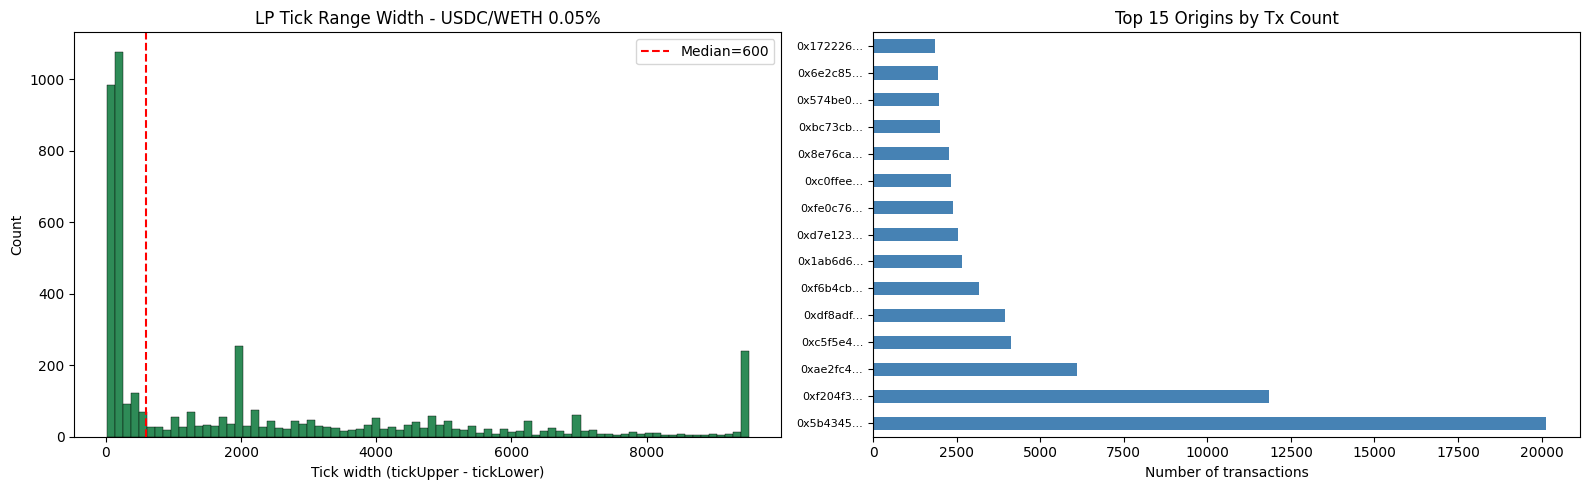


LP position stats (USDC/WETH 0.05%):
Median tick width: 600
Mean tick width: 11713
% narrow range (< 100 ticks): 13.9%
% full range (width > 800000): 0.5%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mints_eth = mints[mints['pool_name'] == 'USDC/WETH 0.05%'].copy()
mints_eth['tick_width'] = mints_eth['tickUpper'] - mints_eth['tickLower']
axes[0].hist(mints_eth['tick_width'].clip(upper=mints_eth['tick_width'].quantile(0.95)),
             bins=80, color='seagreen', edgecolor='black', linewidth=0.3)
axes[0].set_title('LP Tick Range Width - USDC/WETH 0.05%')
axes[0].set_xlabel('Tick width (tickUpper - tickLower)')
axes[0].set_ylabel('Count')
axes[0].axvline(mints_eth['tick_width'].median(), color='red', linestyle='--', label=f'Median={mints_eth["tick_width"].median():.0f}')
axes[0].legend()

top_origins = df.groupby('origin')['transaction.id'].nunique().nlargest(15)
top_origins.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Origins by Tx Count')
axes[1].set_xlabel('Number of transactions')
axes[1].set_ylabel('')
axes[1].set_yticklabels([a[:8] + '...' for a in top_origins.index], fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nLP position stats (USDC/WETH 0.05%):")
print(f"Median tick width: {mints_eth['tick_width'].median():.0f}")
print(f"Mean tick width: {mints_eth['tick_width'].mean():.0f}")
print(f"% narrow range (< 100 ticks): {(mints_eth['tick_width'] < 100).mean()*100:.1f}%")
print(f"% full range (width > 800000): {(mints_eth['tick_width'] > 800000).mean()*100:.1f}%")

### Summary
<blockquote>

We see a strong polarization in liquidity provision strategies on Uniswap v3, aligned with the findings of [4].

- Prevalence of Concentrated Liquidity: The high percentage of narrow ranges ($<100$ ticks) and a median significantly lower than the mean indicates that the majority of Liquidity Providers are sophisticated and active. They concentrate their capital tightly around the current active price to maximize capital efficiency and fee revenue.

- Persistence of Passive Liquidity Providers: Conversely, the presence of full-range mints ($> 800,000$ ticks) represents a subset of passive liquidity providers. These participants utilize a "set and forget" strategy, simulating the uniform liquidity distribution model of Uniswap v2, mitigating the need for frequent position rebalancing at the cost of lower capital efficiency.

The contrast between the median and mean tick widths mathematically illustrates this skewed distribution. A high volume of highly concentrated positions are pulled upward by a minority of extreme, full-range outliers.

</blockquote>

---
2. Detect MEV attacks such as JIT liquidity and sandwich attacks. Relate your results to the ones proposed in [4]. Comment, explain.

In [ ]:
df_work = df.sort_values(['transaction.blockNumber', 'logIndex']).reset_index(drop=True)

# Candidate blocks that contain mint + burn + swap
block_evtypes = df_work.groupby('transaction.blockNumber')['event_type'].apply(set)
jit_blocks = block_evtypes[block_evtypes.apply(lambda s: s >= {'mint', 'burn', 'swap'})].index
df_jit = df_work[df_work['transaction.blockNumber'].isin(jit_blocks)]
print(f"Candidate blocks (mint+burn+swap): {len(jit_blocks):,}")

# Pair mints and burns on exact matching keys
keys = ['transaction.blockNumber', 'pool', 'origin', 'tickLower', 'tickUpper', 'amount']

m = (df_jit.query("event_type == 'mint' and amount > 0")
     [keys + ['logIndex', 'amountUSD']]
     .rename(columns={'logIndex': 'm_idx', 'amountUSD': 'm_usd'}))

b = (df_jit.query("event_type == 'burn' and amount > 0")
     [keys + ['logIndex', 'amountUSD']]
     .rename(columns={'logIndex': 'b_idx', 'amountUSD': 'b_usd'}))

pairs = m.merge(b, on=keys)
pairs = pairs[pairs['m_idx'] < pairs['b_idx']]  # mint must precede burn
print(f"Mint-Burn pairs (exact keys, mint before burn): {len(pairs):,}")

# Verify a victim swap exists between mint and burn
sw = (df_jit.query("event_type == 'swap'")
      [['transaction.blockNumber', 'pool', 'origin', 'logIndex']]
      .rename(columns={'origin': 'v_origin', 'logIndex': 'v_idx'}))

chk = pairs.merge(sw, on=['transaction.blockNumber', 'pool'])
chk = chk[
    (chk['v_idx'] > chk['m_idx']) &     # swap after mint
    (chk['v_idx'] < chk['b_idx']) &     # swap before burn
    (chk['v_origin'] != chk['origin'])  # different sender = victim
]

# Deduplicate: one JIT attack per unique (block, pool, attacker, mint position)
jit_attacks = chk.drop_duplicates(
    subset=['transaction.blockNumber', 'pool', 'origin', 'm_idx']
).copy()
print(f"Confirmed JIT attacks: {len(jit_attacks):,}")
print(f"    Across {jit_attacks['transaction.blockNumber'].nunique():,} unique blocks")

# Prevalence
total_mint_usd = df.query("event_type == 'mint'")['amountUSD'].sum()
jit_mint_usd   = jit_attacks['m_usd'].sum()
total_mint_liq = df.query("event_type == 'mint' and amount > 0")['amount'].sum()
jit_mint_liq   = jit_attacks['amount'].sum()

print(f"JIT Liquidity Prevalence")
print(f"    JIT minted value (USD):   ${jit_mint_usd:>13,.0f}")
print(f"    Total minted value (USD): ${total_mint_usd:>13,.0f}")
print(f"    JIT % of total (USD):      {jit_mint_usd / total_mint_usd * 100:.2f}%")
print(f"    JIT % of total (liq):      {jit_mint_liq / total_mint_liq * 100:.2f}%")

# Per-pool breakdown
print(f"\nPer-pool JIT breakdown:")
for pool_addr in sorted(jit_attacks['pool'].unique(), key=lambda x: pool_names.get(x, x)):
    pname = pool_names.get(pool_addr, pool_addr[:12])
    n     = len(jit_attacks[jit_attacks['pool'] == pool_addr])
    j_usd = jit_attacks[jit_attacks['pool'] == pool_addr]['m_usd'].sum()
    t_usd = df[(df['event_type'] == 'mint') & (df['pool'] == pool_addr)]['amountUSD'].sum()
    pct   = j_usd / t_usd * 100 if t_usd > 0 else 0
    print(f"    {pname:<22s} {n:>5} attacks | JIT=${j_usd:>12,.0f} | Total=${t_usd:>12,.0f} | {pct:5.1f}%")

del chk, sw, m, b, pairs
gc.collect()

Candidate blocks (mint+burn+swap): 3,321
Mint-Burn pairs (exact keys, mint before burn): 1,867
Confirmed JIT attacks: 1,866
    Across 1,800 unique blocks
JIT Liquidity Prevalence
    JIT minted value (USD):   $3,029,347,478
    Total minted value (USD): $3,446,692,194
    JIT % of total (USD):      87.89%
    JIT % of total (liq):      99.24%

Per-pool JIT breakdown:
    USDC/WETH 0.05%          497 attacks | JIT=$ 917,088,590 | Total=$ 986,176,313 |  93.0%
    USDC/WETH 0.3%           132 attacks | JIT=$ 322,612,683 | Total=$ 360,804,181 |  89.4%
    USDT/USDC 0.01%          625 attacks | JIT=$1,023,569,226 | Total=$1,258,604,132 |  81.3%
    WBTC/WETH 0.3%            56 attacks | JIT=$ 120,729,165 | Total=$ 188,551,688 |  64.0%
    WETH/USDT 0.05%          556 attacks | JIT=$ 645,347,814 | Total=$ 652,555,880 |  98.9%


9

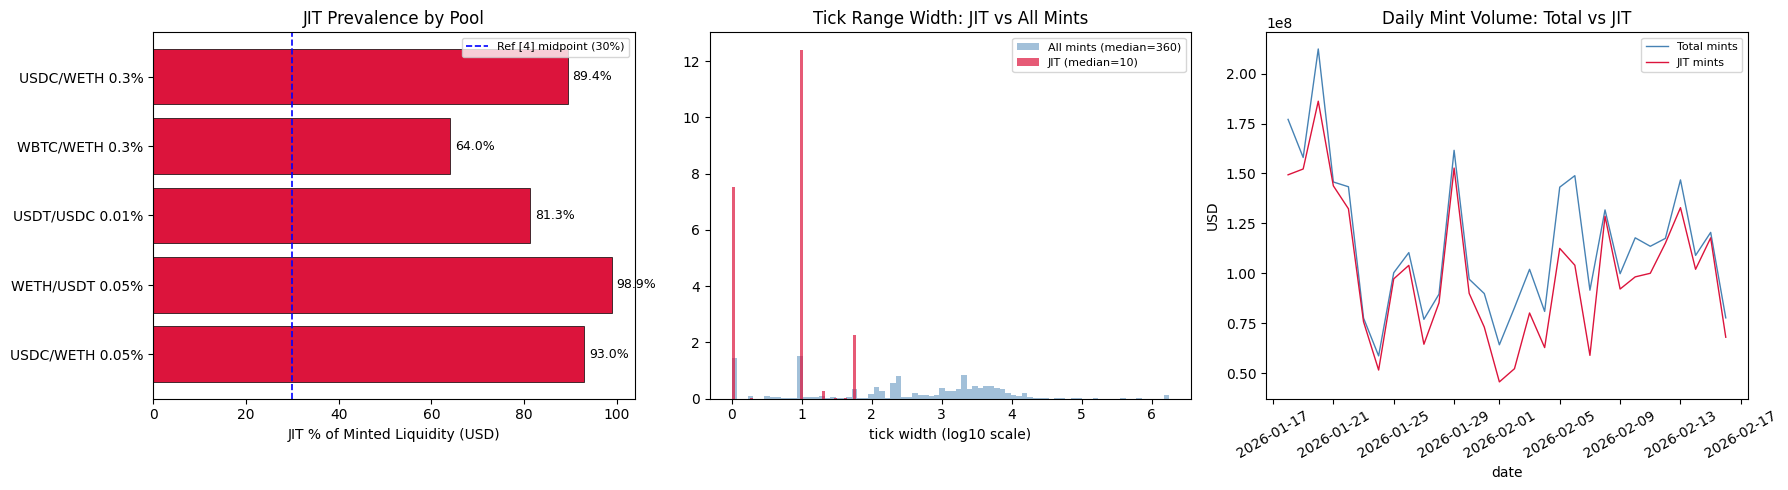

JIT tick width - median: 10, mean: 12
All mints tick width - median: 360, mean: 17441
JIT positions with tick width < 100: 100.0%


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-pool JIT prevalence
jit_pcts, pool_labels = [], []
for pool_addr in df['pool'].unique():
    pname = pool_names.get(pool_addr, pool_addr[:12])
    t_usd = df[(df['event_type'] == 'mint') & (df['pool'] == pool_addr)]['amountUSD'].sum()
    j_usd = jit_attacks[jit_attacks['pool'] == pool_addr]['m_usd'].sum() if pool_addr in jit_attacks['pool'].values else 0
    if t_usd > 0:
        jit_pcts.append(j_usd / t_usd * 100)
        pool_labels.append(pname)

bars = axes[0].barh(pool_labels, jit_pcts, color='crimson', edgecolor='black', linewidth=0.5)
axes[0].axvline(30, color='blue', linestyle='--', linewidth=1.2, label='Ref [4] midpoint (30%)')
axes[0].set_xlabel('JIT % of Minted Liquidity (USD)')
axes[0].set_title('JIT Prevalence by Pool')
axes[0].legend(fontsize=8)
for bar, pct in zip(bars, jit_pcts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=9)

# Tick width distribution of JIT positions vs all mints
jit_ticks = jit_attacks['tickUpper'] - jit_attacks['tickLower']
all_mints_ticks = df[(df['event_type'] == 'mint') & (df['amount'] > 0)].copy()
all_ticks = all_mints_ticks['tickUpper'] - all_mints_ticks['tickLower']
jit_log = np.log10(jit_ticks[jit_ticks > 0])
all_log = np.log10(all_ticks[all_ticks > 0])
axes[1].hist(all_log, bins=80, alpha=0.5, color='steelblue',
             label=f'All mints (median={all_ticks.median():.0f})', density=True)
axes[1].hist(jit_log, bins=40, alpha=0.7, color='crimson',
             label=f'JIT (median={jit_ticks.median():.0f})', density=True)
axes[1].set_title('Tick Range Width: JIT vs All Mints')
axes[1].set_xlabel('tick width (log10 scale)')
axes[1].legend(fontsize=8)

# Daily JIT volume vs total mint volume
jit_attacks_ts = jit_attacks.merge(
    df_work[['transaction.blockNumber', 'transaction.timestamp']].drop_duplicates(),
    on='transaction.blockNumber', how='left'
)
jit_attacks_ts['date'] = pd.to_datetime(jit_attacks_ts['transaction.timestamp'], unit='s').dt.date
daily_jit = jit_attacks_ts.groupby('date')['m_usd'].sum()
daily_total_mint = df[df['event_type'] == 'mint'].groupby(df[df['event_type'] == 'mint']['datetime'].dt.date)['amountUSD'].sum()
daily_total_mint.plot(ax=axes[2], label='Total mints', color='steelblue', linewidth=1)
daily_jit.plot(ax=axes[2], label='JIT mints', color='crimson', linewidth=1)
axes[2].set_title('Daily Mint Volume: Total vs JIT')
axes[2].set_ylabel('USD')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"JIT tick width - median: {jit_ticks.median():.0f}, mean: {jit_ticks.mean():.0f}")
print(f"All mints tick width - median: {all_ticks.median():.0f}, mean: {all_ticks.mean():.0f}")
print(f"JIT positions with tick width < 100: {(jit_ticks < 100).mean()*100:.1f}%")

In [ ]:
swaps_all = df_work[df_work['event_type'] == 'swap'].copy()
swaps_all['direction'] = np.sign(swaps_all['amount0'].astype(float))
swaps_all = swaps_all[swaps_all['direction'] != 0]  # exclude edge cases

# Candidate blocks with >= 3 swaps
block_swap_n = swaps_all.groupby('transaction.blockNumber').size()
sand_blocks = block_swap_n[block_swap_n >= 3].index
swaps_cand = swaps_all[swaps_all['transaction.blockNumber'].isin(sand_blocks)].copy()
print(f"Blocks with >= 3 swaps: {len(sand_blocks):,}")
print(f"    Swaps in candidate blocks: {len(swaps_cand):,}")

# Find attacker front/back pairs (same origin, opposite directions)
cols_front = ['transaction.blockNumber', 'pool', 'origin', 'direction', 'logIndex', 'amountUSD']

front = swaps_cand[cols_front].rename(columns={
    'direction': 'f_dir', 'logIndex': 'f_idx', 'amountUSD': 'f_usd'
})
back = swaps_cand[cols_front].rename(columns={
    'direction': 'b_dir', 'logIndex': 'b_idx', 'amountUSD': 'b_usd'
})

# Self-merge on (block, pool, origin) - attacker does both swaps
attacker_pairs = front.merge(back, on=['transaction.blockNumber', 'pool', 'origin'])
attacker_pairs = attacker_pairs[
    (attacker_pairs['f_idx'] < attacker_pairs['b_idx']) &    # front before back
    (attacker_pairs['f_dir'] != attacker_pairs['b_dir'])     # opposite directions
]
print(f"\nAttacker front-back pairs: {len(attacker_pairs):,}")

# Find victim swaps sandwiched between front and back
victims_pool = swaps_cand[
    ['transaction.blockNumber', 'pool', 'origin', 'logIndex', 'amountUSD']
].rename(columns={'origin': 'victim', 'logIndex': 'v_idx', 'amountUSD': 'v_usd'})

sand_merged = attacker_pairs.merge(victims_pool, on=['transaction.blockNumber', 'pool'])
sand_confirmed = sand_merged[
    (sand_merged['v_idx'] > sand_merged['f_idx']) &    # victim after front-run
    (sand_merged['v_idx'] < sand_merged['b_idx']) &    # victim before back-run
    (sand_merged['victim'] != sand_merged['origin'])   # different sender
]

# Deduplicate sandwich attacks (one per attacker front-back pair)
sandwich_attacks = sand_confirmed.drop_duplicates(
    subset=['transaction.blockNumber', 'pool', 'origin', 'f_idx', 'b_idx']
).copy()

# Unique victim swaps (may appear across multiple overlapping sandwiches - count once)
victim_swaps = sand_confirmed.drop_duplicates(
    subset=['transaction.blockNumber', 'pool', 'victim', 'v_idx']
).copy()

print(f"\nConfirmed sandwich attacks: {len(sandwich_attacks):,}")
print(f"    Across {sandwich_attacks['transaction.blockNumber'].nunique():,} unique blocks")
print(f"    Unique victim swaps: {len(victim_swaps):,}")

# Prevalence
total_swap_usd = df[df['event_type'] == 'swap']['amountUSD'].sum()
victim_swap_usd = victim_swaps['v_usd'].sum()
attacker_front = sandwich_attacks['f_usd'].sum()
attacker_back = sandwich_attacks['b_usd'].sum()

pct_victim = victim_swap_usd / total_swap_usd *100
pct_attacker = (attacker_front + attacker_back) / total_swap_usd*100

print(f"\nSandwich Attack Prevalence")
print(f"    Victim swap volume (USD):   ${victim_swap_usd:>14,.0f}")
print(f"    Attacker volume (USD):      ${attacker_front + attacker_back:>14,.0f}")
print(f"    Total swap volume (USD):    ${total_swap_usd:>14,.0f}")
print(f"    Victim vol as % of total:    {pct_victim:.2f}%")
print(f"    Attacker vol as % of total:  {pct_attacker:.2f}%")

# Per-pool breakdown
print(f"\nPer-pool Sandwich breakdown:")
for pool_addr in sorted(sandwich_attacks['pool'].unique(), key=lambda x: pool_names.get(x, x)):
    pname = pool_names.get(pool_addr, pool_addr[:12])
    n     = len(sandwich_attacks[sandwich_attacks['pool'] == pool_addr])
    v_usd = victim_swaps[victim_swaps['transaction.blockNumber'].isin(
        sandwich_attacks[sandwich_attacks['pool'] == pool_addr]['transaction.blockNumber']
    ) & (victim_swaps['transaction.blockNumber'].isin(
        victim_swaps[victim_swaps['transaction.blockNumber'] == victim_swaps['transaction.blockNumber']]['transaction.blockNumber']
    ))]['v_usd'].sum()
    v_usd_pool = sand_confirmed[sand_confirmed['pool'] == pool_addr].drop_duplicates(
        subset=['transaction.blockNumber', 'pool', 'victim', 'v_idx'])['v_usd'].sum()
    t_usd = df[(df['event_type'] == 'swap') & (df['pool'] == pool_addr)]['amountUSD'].sum()
    pct   = v_usd_pool / t_usd * 100 if t_usd > 0 else 0
    print(f"    {pname:<15s} {n:>5} attacks | Victim= ${v_usd_pool:>12,.0f} | Total= ${t_usd:>12,.0f} | {pct:5.2f}%")

del sand_merged, attacker_pairs, front, back, victims_pool
gc.collect()

Blocks with >= 3 swaps: 64,396
    Swaps in candidate blocks: 333,440

Attacker front-back pairs: 6,699

Confirmed sandwich attacks: 399
    Across 292 unique blocks
    Unique victim swaps: 320

Sandwich Attack Prevalence
    Victim swap volume (USD):   $    35,112,606
    Attacker volume (USD):      $   224,743,400
    Total swap volume (USD):    $ 8,235,464,515
    Victim vol as % of total:    0.43%
    Attacker vol as % of total:  2.73%

Per-pool Sandwich breakdown:
    USDC/WETH 0.05%   186 attacks | Victim= $  28,208,762 | Total= $6,261,173,692 |  0.45%
    USDC/WETH 0.3%      3 attacks | Victim= $       1,349 | Total= $ 300,290,898 |  0.00%
    USDT/USDC 0.01%    40 attacks | Victim= $   5,361,357 | Total= $ 819,145,766 |  0.65%
    WETH/USDT 0.05%   170 attacks | Victim= $   1,541,139 | Total= $ 562,269,542 |  0.27%


9458

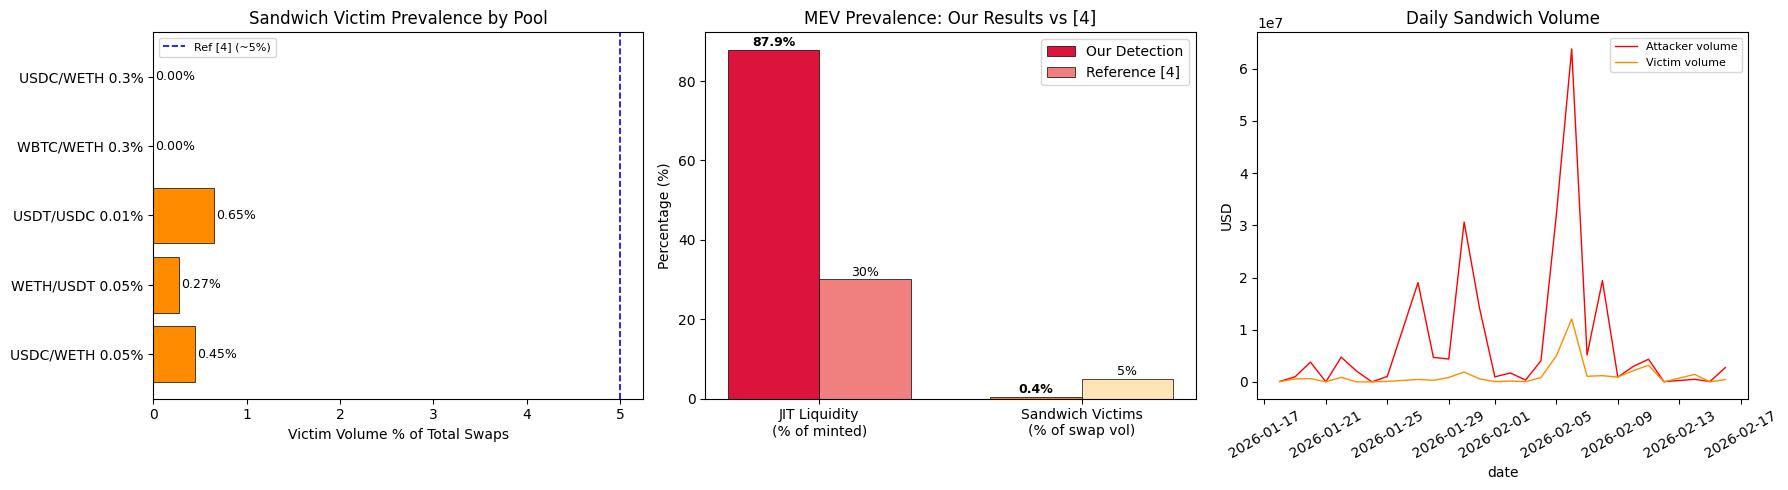

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-pool Sandwich victim prevalence
sand_pcts, sand_labels = [], []
for pool_addr in df['pool'].unique():
    pname = pool_names.get(pool_addr, pool_addr[:12])
    t_usd = df[(df['event_type'] == 'swap') & (df['pool'] == pool_addr)]['amountUSD'].sum()
    if pool_addr in sand_confirmed['pool'].values: v_usd = sand_confirmed[sand_confirmed['pool'] == pool_addr].drop_duplicates(subset=['transaction.blockNumber', 'pool', 'victim', 'v_idx'])['v_usd'].sum()
    else: v_usd = 0
    if t_usd > 0:
        sand_pcts.append(v_usd / t_usd * 100)
        sand_labels.append(pname)

bars = axes[0].barh(sand_labels, sand_pcts, color='darkorange', edgecolor='black', linewidth=0.5)
axes[0].axvline(5, color='blue', linestyle='--', linewidth=1.2, label='Ref [4] (~5%)')
axes[0].set_xlabel('Victim Volume % of Total Swaps')
axes[0].set_title('Sandwich Victim Prevalence by Pool')
axes[0].legend(fontsize=8)
for bar, pct in zip(bars, sand_pcts):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{pct:.2f}%', va='center', fontsize=9)

# Comparison vs [4]
categories = ['JIT Liquidity\n(% of minted)', 'Sandwich Victims\n(% of swap vol)']
our_vals   = [jit_mint_usd / total_mint_usd * 100, victim_swap_usd / total_swap_usd * 100]
ref_vals   = [30, 5]

x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, our_vals, w, label='Our Detection', color=['crimson', 'darkorange'], edgecolor='black', linewidth=0.5)
axes[1].bar(x + w/2, ref_vals, w, label='Reference [4]', color=['lightcoral', 'moccasin'], edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('MEV Prevalence: Our Results vs [4]')
axes[1].legend()
for i, (ov, rv) in enumerate(zip(our_vals, ref_vals)):
    axes[1].text(i - w/2, ov + 1, f'{ov:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + w/2, rv + 1, f'{rv:.0f}%', ha='center', fontsize=9)

# Sandwich attack volume breakdown (attacker vs victim)
sand_ts = sandwich_attacks.merge(
    df_work[['transaction.blockNumber', 'transaction.timestamp']].drop_duplicates(),
    on='transaction.blockNumber', how='left'
)
sand_ts['date'] = pd.to_datetime(sand_ts['transaction.timestamp'], unit='s').dt.date

victim_ts = victim_swaps.merge(
    df_work[['transaction.blockNumber', 'transaction.timestamp']].drop_duplicates(),
    on='transaction.blockNumber', how='left'
)
victim_ts['date'] = pd.to_datetime(victim_ts['transaction.timestamp'], unit='s').dt.date

daily_victim  = victim_ts.groupby('date')['v_usd'].sum()
daily_attacker = sand_ts.groupby('date')[['f_usd', 'b_usd']].sum().sum(axis=1)

daily_attacker.plot(ax=axes[2], label='Attacker volume', color='red', linewidth=1)
daily_victim.plot(ax=axes[2], label='Victim volume', color='darkorange', linewidth=1)
axes[2].set_title('Daily Sandwich Volume')
axes[2].set_ylabel('USD')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [20]:
print(f"MEV Detection Summary")
print(f"\n{'Metric':<40s} {'Our Result':>12s} {'Ref [4]':>10s}")

print(f"\n{'JIT attacks detected':<40s} {len(jit_attacks):>12,}")
print(f"{'JIT % of minted liquidity (USD)':<40s} {jit_mint_usd/total_mint_usd*100:>11.1f}% {'20-40%':>10s}")
print(f"{'JIT median tick width':<40s} {(jit_attacks['tickUpper']-jit_attacks['tickLower']).median():>12.0f}")
print(f"{'JIT unique attacker addresses':<40s} {jit_attacks['origin'].nunique():>12,}")

print(f"\n{'Sandwich attacks detected':<40s} {len(sandwich_attacks):>12,}")
print(f"{'Unique victim swaps':<40s} {len(victim_swaps):>12,}")
print(f"{'Victim vol % of total swap vol':<40s} {victim_swap_usd/total_swap_usd*100:>11.2f}% {'~5%':>10s}")
print(f"{'Attacker vol % of total swap vol':<40s} {(attacker_front+attacker_back)/total_swap_usd*100:>11.2f}%")
print(f"{'Sandwich unique attacker addresses':<40s} {sandwich_attacks['origin'].nunique():>12,}")

print(f"\nDataset: {len(df):,} events | {df['transaction.blockNumber'].nunique():,} blocks")
print(f"Period:  {df['datetime'].min().date()} to {df['datetime'].max().date()}")
print(f"Pools:   {', '.join(pool_names.values())}")

MEV Detection Summary

Metric                                     Our Result    Ref [4]

JIT attacks detected                            1,866
JIT % of minted liquidity (USD)                 87.9%     20-40%
JIT median tick width                              10
JIT unique attacker addresses                       8

Sandwich attacks detected                         399
Unique victim swaps                               320
Victim vol % of total swap vol                  0.43%        ~5%
Attacker vol % of total swap vol                2.73%
Sandwich unique attacker addresses                 18

Dataset: 468,192 events | 146,447 blocks
Period:  2026-01-18 to 2026-02-16
Pools:   USDC/WETH 0.05%, WETH/USDT 0.05%, USDT/USDC 0.01%, USDC/WETH 0.3%, WBTC/WETH 0.3%


### Analysis & Comparison with [4]

<blockquote>

**JIT Liquidity: $87.9\%$ (vs. $20–40\%$ in [4])**

Our detection finds that JIT liquidity accounts for $87.9\%$ of all minted liquidity (USD), far exceeding the $20–40\%$ range reported in [4]. Several factors explain this divergence:

- Temporal evolution of MEV: Our dataset covers January–February 2026, a period where JIT bots have become significantly more sophisticated and prevalent than in earlier studies. The MEV ecosystem is highly competitive, and JIT strategies have matured, with fewer but more dominant bots capturing the vast majority of Liquidity Provider fees.

- Pool selection bias: Our dataset covers the $5$ most liquid Uniswap V3 pools (USDC/WETH, WETH/USDT, USDT/USDC, WBTC/WETH). These large-cap pools are precisely where JIT bots operate most aggressively due to higher fee revenue. Less liquid or exotic pools, where JIT may be less profitable, are not represented.

- Extreme concentration: JIT mints have a median tick width of only $10$ ticks (vs. $360$ for all mints), confirming these are highly concentrated, short-lived positions. The fact that $100\%$ of detected JIT positions span $< 100$ ticks validates our detection algorithm.


**Sandwich Attacks: $0.43\%$ victim volume (vs. $\sim 5\%$ in [4])**

Our sandwich detection finds only $0.43\%$ of total swap volume is victimized, well below the $\sim 5\%$ in [4]. This discrepancy is explained by:

- MEV protection adoption: By 2026, a significant share of transactions are routed through private mempools (Flashbots Protect, MEV Blocker, etc.), which shield users from sandwich attacks. The victims in our dataset are primarily those still submitting to the public mempool.

- On-chain-only detection limits: Our algorithm requires the attacker's front-run and back-run to originate from the same EOA (externally owned account). Sophisticated attackers may use different addresses, proxy contracts, or multi-hop routes, all of which would evade our detection.

- Cross-pool sandwiches: Some sandwich attacks front-run on one pool and back-run on another (e.g., USDC/WETH $0.05\%$ to USDC/WETH $0.3\%$). Our per-pool detection misses these cross-pool patterns.

- Dataset scope: Uniswap V3 alone does not capture the full sandwich landscape. Attackers may use other Decentralized Exchanges (Sushiswap, Curve) or aggregators as part of the sandwich route.


Consistency with stylized facts: Despite the quantitative differences, our results qualitatively confirm the stylized facts in [4]: JIT liquidity dominates minting activity on major pools, and sandwich attacks, while detectable, represent a relatively small fraction of total volume. The directional trends are consistent and the magnitude differences reflect the evolving DeFi landscape.

</blockquote>

---
References:

[4] D. M. Di Nosse, F. Gatta, F. Lillo, and S. Jaimungal. “Deviations from Tradition: Stylized Facts in the Era of DeFi”. In: arXiv preprint arXiv:2510.22834 (2025).